In [1]:
# Imports and repo setup.
from pathlib import Path
from collections import Counter
from dataclasses import asdict, dataclass
from io import BytesIO
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names
from calvin_experiments.train_dynamics_world_model import load_dynamics_model_for_eval

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
cuda: True


In [2]:
# Load the policy, automaton world model, and local dynamics world model.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
DYNAMICS_CKPT_PATH = REPO_ROOT / "outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/F_drawer_G_constraint"
VIDEO_FPS = 30

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")
TARGET_LABEL_NAME = "drawer_open"
TARGET_LABEL_IDX = label_names.index(TARGET_LABEL_NAME)

dynamics_model, dynamics_stats, dynamics_ckpt, dynamics_meta = load_dynamics_model_for_eval(DYNAMICS_CKPT_PATH, device=DEVICE)
dynamics_model.eval()
dynamics_stats_t = {k: torch.as_tensor(v, device=DEVICE, dtype=torch.float32).unsqueeze(0) for k, v in dynamics_stats.items()}

print("device:", DEVICE)
print("labels:", label_names)
print("target:", TARGET_LABEL_NAME, TARGET_LABEL_IDX)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("dynamics:", DYNAMICS_CKPT_PATH)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['eye_in_hand', 'third_person']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
labels: ['switch_on', 'switch_off', 'button_on', 'button_off', 'button_pressed', 'drawer_open', 'drawer_closed', 'door_left', 'door_right']
target: drawer_open 5
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38
dynamics: /home/moritz/src/guided-diffusion/outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08


In [3]:
# Rollout helpers and automaton sample-and-rank utilities.
env = None
base_env_state = None

def robot_obs_with_target_xy(env, robot_obs, start_xy):
    import pybullet as p

    robot_obs = np.asarray(robot_obs, dtype=np.float32).copy()
    target_pos = robot_obs[:3].copy()
    target_pos[:2] = np.asarray(start_xy, dtype=np.float32)
    target_orn = p.getQuaternionFromEuler(robot_obs[3:6])

    robomimic_env = env.env if hasattr(env, "_get_initial_obs_history") else env
    gym_env = getattr(robomimic_env, "env", None)
    robot = getattr(gym_env, "robot", None)
    if robot is None or not hasattr(robot, "mixed_ik"):
        robot_obs[:2] = target_pos[:2]
        return robot_obs

    labels = robot.get_observation_labels()
    joint_indices = [i for i, name in enumerate(labels) if name.startswith("robot_joint")]
    joint_states = robot.mixed_ik.get_ik(target_pos, target_orn)
    robot_obs[:3] = target_pos
    robot_obs[joint_indices] = np.asarray(joint_states[:len(joint_indices)], dtype=np.float32)
    return robot_obs

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def validate_target_label_idx(target_label_idx):
    idx = int(target_label_idx)
    if idx < 0 or idx >= len(label_names):
        raise ValueError(f"target_label_idx {idx} out of range for labels {label_names}")
    return idx

def opposite_label_idx(target_label_idx):
    opposites = {
        "switch_on": "switch_off", "switch_off": "switch_on",
        "button_on": "button_off", "button_off": "button_on",
        "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
        "door_left": "door_right", "door_right": "door_left",
    }
    name = opposites.get(label_names[int(target_label_idx)])
    return None if name is None or name not in label_names else label_names.index(name)

def score_label_probs(label_probs, target_label_idx):
    scores = np.asarray(label_probs, dtype=np.float32)[..., int(target_label_idx)].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {key: value.repeat((int(n),) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {key: policy.action_normalization_stats[key]["offset"].shape[1:] for key in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    automaton_horizon = len(automaton_stats["actions_mean"]) // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=200, save_video=True, stop_when_complete=True, start_xy=None):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
    if start_xy is not None:
        fixed_robot = robot_obs_with_target_xy(env, fixed_robot, start_xy)

    CRU.seed_everything(seed)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = CRU.capture_scene_snapshot(env)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)
    if hasattr(action_sampler, "sync"):
        action_sampler.sync(label0, 0)

    actions, rewards, dones, records = [], [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    action_queue = []
    first_behavior, first_behavior_step = "none", -1
    termination_reason = "horizon"

    for step in range(int(horizon)):
        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        _, current_label = current_automaton_state_and_label(env)

        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if first_behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            first_behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            first_behavior_step = step + 1

        if hasattr(action_sampler, "sync"):
            advanced = action_sampler.sync(current_label, step + 1)
            if advanced:
                action_queue.clear()
            if stop_when_complete and action_sampler.done:
                termination_reason = "target_complete"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    complete = bool(getattr(action_sampler, "done", False))
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed),
        "start_xy": None if start_xy is None else [float(start_xy[0]), float(start_xy[1])],
        "guidance_scale": float(getattr(action_sampler, "guidance_scale", 0.0)),
        "behavior": TARGET_LABEL_NAME if complete else first_behavior,
        "target_complete": complete, "first_behavior": first_behavior, "first_behavior_step": int(first_behavior_step),
        "behavior_step": int(action_sampler.events[-1]["step"] if getattr(action_sampler, "events", []) else first_behavior_step),
        "termination_step": len(actions), "termination_reason": termination_reason,
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "gripper_width": np.asarray(robot_states, dtype=np.float32)[:, 6],
        "initial_label": label0.astype(int).tolist(), "final_label": labelf.astype(int).tolist(),
        "records": records, "target_events": list(getattr(action_sampler, "events", [])), "scene_snapshot": scene_snapshot,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=VIDEO_FPS)
    return rollout


In [4]:
# Gripper-open robustness and local dynamics-guided post-sample action refinement.
# Dynamics rot6d state layout: [tcp_xyz 0:3, tcp_rot6d 3:9, gripper_width 9, joints/actions 10:18, scene ...].
GRIPPER_WIDTH_DYN_IDX = 9
GRIPPER_WIDTH_RAW_ROBOT_IDX = 6
GRIPPER_ACTION_IDX = -1
GRIPPER_OPEN_ACTION = 1.0  # CALVIN env action convention: +1 opens/keeps open, -1 closes.

@dataclass
class GripperOpenSpec:
    min_width: float = 0.06
    margin: float = 0.02

    def normalized(self):
        return GripperOpenSpec(float(self.min_width), float(max(self.margin, 0.0)))

def euler_xyz_to_rot6d_torch(euler_xyz):
    x, y, z = euler_xyz[..., 0], euler_xyz[..., 1], euler_xyz[..., 2]
    sx, cx = torch.sin(x), torch.cos(x)
    sy, cy = torch.sin(y), torch.cos(y)
    sz, cz = torch.sin(z), torch.cos(z)
    return torch.stack([cz * cy, sz * cy, -sy, cz * sy * sx - sz * cx, sz * sy * sx + cz * cx, cy * sx], dim=-1)

def raw_env_state_to_dynamics_state_torch(robot, scene):
    robot_t = torch.as_tensor(robot, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    scene_t = torch.as_tensor(scene, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    robot_dyn = torch.cat([robot_t[..., :3], euler_xyz_to_rot6d_torch(robot_t[..., 3:6]), robot_t[..., 6:]], dim=-1)
    scene_parts = [scene_t[..., :6]]
    for start in (6, 12, 18):
        scene_parts += [scene_t[..., start:start + 3], euler_xyz_to_rot6d_torch(scene_t[..., start + 3:start + 6])]
    return torch.cat([robot_dyn, torch.cat(scene_parts, dim=-1)], dim=-1)

def project_rot6d_torch(rot6d):
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r1 = r1 / (torch.linalg.norm(r1, dim=-1, keepdim=True) + 1e-8)
    r2 = r2 - torch.sum(r1 * r2, dim=-1, keepdim=True) * r1
    r2 = r2 / (torch.linalg.norm(r2, dim=-1, keepdim=True) + 1e-8)
    return torch.cat([r1, r2], dim=-1)

def project_dynamics_state_torch(state):
    pieces, cursor = [], 0
    for start, end in [(3, 9), (27, 33), (36, 42), (45, 51)]:
        pieces += [state[..., cursor:start], project_rot6d_torch(state[..., start:end])]
        cursor = end
    return torch.cat(pieces + [state[..., cursor:]], dim=-1)

def dynamics_rollout_torch(state_dyn, action_chunk):
    if action_chunk.ndim == 2:
        action_chunk = action_chunk.unsqueeze(0)
    state = state_dyn.expand(action_chunk.shape[0], -1)
    states = []
    for t in range(action_chunk.shape[1]):
        state_n = (state - dynamics_stats_t["state_mean"]) / dynamics_stats_t["state_std"]
        action_n = (action_chunk[:, t, :] - dynamics_stats_t["action_mean"]) / dynamics_stats_t["action_std"]
        delta_n = dynamics_model(state_n, action_n)
        delta = delta_n * dynamics_stats_t["delta_std"] + dynamics_stats_t["delta_mean"]
        state = project_dynamics_state_torch(state + delta)
        states.append(state)
    return torch.stack(states, dim=1)

def dynamics_xy_width_torch(state_dyn, action_chunk):
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    return pred_states[..., 0:2], pred_states[..., GRIPPER_WIDTH_DYN_IDX]

def raw_gripper_width_robustness_torch(state_dyn, action_chunk, smooth_min_tau=0.01):
    _, gripper_width = dynamics_xy_width_torch(state_dyn, action_chunk)
    # Raw value objective: maximize predicted opening width throughout the branch.
    # Mean width gives useful gradients to every gripper command in the chunk; the
    # record still reports min_width_before/after for the actual G-style check.
    return gripper_width.mean(dim=-1), gripper_width

def gripper_open_robustness_torch(state_dyn, action_chunk, spec, smooth_min_tau=0.01):
    spec = spec.normalized()
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    gripper_width = pred_states[..., GRIPPER_WIDTH_DYN_IDX]
    width_margin = gripper_width - float(spec.min_width)
    capped = torch.clamp(width_margin, max=float(spec.margin))
    tau = max(float(smooth_min_tau), 1e-6)
    smooth_min = -tau * torch.logsumexp(-capped / tau, dim=-1)
    return smooth_min, gripper_width

def refine_action_chunk_for_gripper_open(
    robot, scene, action_chunk, spec, guidance_scale=1.0, gradient_steps=8, step_size=0.03,
    action_reg=0.05, smooth_min_tau=0.01, mode="world_model_gripper_value_only", gripper_action_idx=GRIPPER_ACTION_IDX,
    gripper_open_action=GRIPPER_OPEN_ACTION,
):
    state_dyn = raw_env_state_to_dynamics_state_torch(robot, scene)
    original = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        robust_before, width_before = gripper_open_robustness_torch(state_dyn, original, spec, smooth_min_tau)
        pred_xy_before, _ = dynamics_xy_width_torch(state_dyn, original)

    if float(guidance_scale) <= 0.0:
        record = {
            "mode": "disabled",
            "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_before[0].cpu()),
            "min_width_before": float(width_before[0].min().cpu()), "min_width_after": float(width_before[0].min().cpu()),
            "pred_width_before": width_before[0].detach().cpu().numpy().tolist(), "pred_width_after": width_before[0].detach().cpu().numpy().tolist(),
            "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_before[0].detach().cpu().numpy().tolist(),
            "action_l2_change": 0.0, "non_gripper_l2_change": 0.0, "gripper_l2_change": 0.0, "history": [],
        }
        return np.asarray(action_chunk, dtype=np.float32), record

    # Baseline/debug mode only: direct command override. The research-method default below is
    # world_model_gripper_value_only, which optimizes action[-1] through the dynamics model.
    if mode == "command_override":
        refined_np = np.asarray(action_chunk, dtype=np.float32).copy()
        refined_np[..., int(gripper_action_idx)] = float(gripper_open_action)
        refined = torch.as_tensor(refined_np[None], device=DEVICE, dtype=torch.float32)
        with torch.no_grad():
            robust_after, width_after = gripper_open_robustness_torch(state_dyn, refined, spec, smooth_min_tau)
            pred_xy_after, _ = dynamics_xy_width_torch(state_dyn, refined)
        delta = refined - original
        nongrip = delta.clone(); nongrip[..., int(gripper_action_idx)] = 0.0
        grip = delta[..., int(gripper_action_idx)]
        record = {
            "mode": mode,
            "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_after[0].cpu()),
            "min_width_before": float(width_before[0].min().cpu()), "min_width_after": float(width_after[0].min().cpu()),
            "pred_width_before": width_before[0].detach().cpu().numpy().tolist(), "pred_width_after": width_after[0].detach().cpu().numpy().tolist(),
            "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_after[0].detach().cpu().numpy().tolist(),
            "action_l2_change": float(torch.linalg.norm(delta).detach().cpu()),
            "non_gripper_l2_change": float(torch.linalg.norm(nongrip).detach().cpu()),
            "gripper_l2_change": float(torch.linalg.norm(grip).detach().cpu()),
            "gripper_action_before": original[0, :, int(gripper_action_idx)].detach().cpu().numpy().tolist(),
            "gripper_action_after": refined[0, :, int(gripper_action_idx)].detach().cpu().numpy().tolist(),
            "history": [],
        }
        return refined_np.astype(np.float32), record

    if int(gradient_steps) <= 0:
        record = {
            "mode": "disabled_no_steps",
            "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_before[0].cpu()),
            "min_width_before": float(width_before[0].min().cpu()), "min_width_after": float(width_before[0].min().cpu()),
            "pred_width_before": width_before[0].detach().cpu().numpy().tolist(), "pred_width_after": width_before[0].detach().cpu().numpy().tolist(),
            "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_before[0].detach().cpu().numpy().tolist(),
            "action_l2_change": 0.0, "non_gripper_l2_change": 0.0, "gripper_l2_change": 0.0, "history": [],
        }
        return np.asarray(action_chunk, dtype=np.float32), record

    if mode not in {"world_model_all_actions", "world_model_gripper_only", "world_model_gripper_value_only", "world_model_gripper_value_all_actions"}:
        raise ValueError(f"Unknown gripper guidance mode: {mode}")

    actions = original.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([actions], lr=float(step_size))
    history = []
    for _ in range(int(gradient_steps)):
        opt.zero_grad(set_to_none=True)
        action_eval = actions
        if mode in {"world_model_gripper_only", "world_model_gripper_value_only"}:
            action_eval = original.clone()
            action_eval[..., int(gripper_action_idx)] = actions[..., int(gripper_action_idx)]
        if mode in {"world_model_gripper_value_only", "world_model_gripper_value_all_actions"}:
            robust, width = raw_gripper_width_robustness_torch(state_dyn, action_eval, smooth_min_tau)
        else:
            robust, width = gripper_open_robustness_torch(state_dyn, action_eval, spec, smooth_min_tau)
        delta = action_eval - original
        action_penalty = torch.mean(delta ** 2, dim=(1, 2))
        objective = float(guidance_scale) * robust - float(action_reg) * action_penalty
        (-objective.mean()).backward()
        opt.step()
        with torch.no_grad():
            if mode in {"world_model_gripper_only", "world_model_gripper_value_only"}:
                keep = original.clone(); keep[..., int(gripper_action_idx)] = actions[..., int(gripper_action_idx)]
                actions.copy_(keep)
            actions.clamp_(-1.0, 1.0)
            history.append({
                "robustness": float(robust[0].detach().cpu()), "min_width": float(width[0].min().detach().cpu()),
                "action_penalty": float(action_penalty[0].detach().cpu()), "objective": float(objective[0].detach().cpu()),
            })
    with torch.no_grad():
        if mode in {"world_model_gripper_value_only", "world_model_gripper_value_all_actions"}:
            robust_after, width_after = raw_gripper_width_robustness_torch(state_dyn, actions, smooth_min_tau)
        else:
            robust_after, width_after = gripper_open_robustness_torch(state_dyn, actions, spec, smooth_min_tau)
        pred_xy_after, _ = dynamics_xy_width_torch(state_dyn, actions)
    delta = actions - original
    nongrip = delta.clone(); nongrip[..., int(gripper_action_idx)] = 0.0
    grip = delta[..., int(gripper_action_idx)]
    record = {
        "mode": mode,
        "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_after[0].cpu()),
        "min_width_before": float(width_before[0].min().cpu()), "min_width_after": float(width_after[0].min().cpu()),
        "pred_width_before": width_before[0].detach().cpu().numpy().tolist(), "pred_width_after": width_after[0].detach().cpu().numpy().tolist(),
        "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_after[0].detach().cpu().numpy().tolist(),
        "action_l2_change": float(torch.linalg.norm(delta).detach().cpu()),
        "non_gripper_l2_change": float(torch.linalg.norm(nongrip).detach().cpu()),
        "gripper_l2_change": float(torch.linalg.norm(grip).detach().cpu()),
        "gripper_action_before": original[0, :, int(gripper_action_idx)].detach().cpu().numpy().tolist(),
        "gripper_action_after": actions[0, :, int(gripper_action_idx)].detach().cpu().numpy().tolist(),
        "history": history,
    }
    return actions[0].detach().cpu().numpy().astype(np.float32), record

def sync_target_event(label, step, target_label_idx, events):
    if len(events) == 0 and float(label[int(target_label_idx)]) > 0.5:
        events.append({"step": int(step), "target_idx": int(target_label_idx), "target_name": label_names[int(target_label_idx)]})
        return True
    return False

def make_drawer_gripper_action_sampler(target_label_idx, n_candidates, gripper_spec, guidance_scale=1.0, gradient_steps=8, step_size=0.03, action_reg=0.05, smooth_min_tau=0.01, guidance_mode="world_model_gripper_value_only"):
    target_label_idx = validate_target_label_idx(target_label_idx)
    n_candidates = int(n_candidates)
    events = []

    def sync(label, step):
        advanced = sync_target_event(label, step, target_label_idx, events)
        action_sampler.events = events
        action_sampler.done = len(events) > 0
        return advanced

    def action_sampler(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        sync(automaton_label, step)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
        candidate_scores = score_label_probs(candidate_probs, target_label_idx)
        selected_idx = int(np.argmax(candidate_scores))
        selected = np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32)

        state = env.get_state()
        refined, gripper_record = refine_action_chunk_for_gripper_open(
            state["robot"], state["scene"], selected, gripper_spec,
            guidance_scale=guidance_scale, gradient_steps=gradient_steps, step_size=step_size,
            action_reg=action_reg, smooth_min_tau=smooth_min_tau, mode=guidance_mode,
        )
        opp = opposite_label_idx(target_label_idx)
        record = {
            "t": int(step), "selected_idx": selected_idx, "target_idx": int(target_label_idx), "target_name": label_names[target_label_idx],
            "opposite_label_idx": None if opp is None else int(opp), "opposite_label_name": None if opp is None else label_names[opp],
            "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, target_label_idx]),
            "selected_opposite_prob": None if opp is None else float(candidate_probs[selected_idx, opp]),
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
            "selected_action_before": selected.tolist(), "selected_action_after": refined.tolist(),
            "gripper": gripper_record,
        }
        return refined, record

    action_sampler.sync = sync
    action_sampler.done = False
    action_sampler.events = events
    action_sampler.guidance_scale = float(guidance_scale)
    return action_sampler


In [5]:
# Experiment knobs and rollout loop. This runs 4 baseline starts and 4 gripper-guided starts.
SEEDS = [0]
START_XS = [0.1]
START_YS = [-0.1]
START_XY_LIST = [(x, y) for x in START_XS for y in START_YS]
GUIDANCE_SCALES = [0.0, 100.0]
N_CANDIDATES = 32
HORIZON = 200
SAVE_VIDEO = True

GRIPPER_SPEC = GripperOpenSpec(min_width=0.06, margin=0.02)
GRIPPER_GUIDANCE_MODE = "world_model_gripper_value_only"  # WM gradient over action[-1] only; baseline/debug options: command_override, world_model_gripper_only, world_model_all_actions
GRADIENT_STEPS = 50
STEP_SIZE = 0.10
ACTION_REG = 0.001
SMOOTH_MIN_TAU = 0.01

def scale_tag(scale):
    return f"scale_{float(scale):.3g}".replace("-", "m").replace(".", "p")

def start_xy_tag(start_xy):
    return f"x{start_xy[0]:+.2f}_y{start_xy[1]:+.2f}".replace("+", "p").replace("-", "m").replace(".", "p")

run_dir = OUTPUT_ROOT / time.strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=False)

rollouts = []
for guidance_scale in GUIDANCE_SCALES:
    for seed in SEEDS:
        for start_xy in START_XY_LIST:
            action_sampler = make_drawer_gripper_action_sampler(
                TARGET_LABEL_IDX, N_CANDIDATES, GRIPPER_SPEC,
                guidance_scale=guidance_scale, gradient_steps=GRADIENT_STEPS, step_size=STEP_SIZE,
                action_reg=ACTION_REG, smooth_min_tau=SMOOTH_MIN_TAU, guidance_mode=GRIPPER_GUIDANCE_MODE,
            )
            tag = f"F_drawer_G_gripper_{scale_tag(guidance_scale)}_{start_xy_tag(start_xy)}_seed_{seed:03d}"
            rollout = rollout_policy_once(seed, action_sampler, run_dir, tag, horizon=HORIZON, save_video=SAVE_VIDEO, start_xy=start_xy)
            rollout["gripper_violation"] = bool(np.min(rollout["gripper_width"]) < GRIPPER_SPEC.min_width)
            rollouts.append(rollout)
            print(
                f"scale={guidance_scale:>5g} start={start_xy} seed={seed:03d}: "
                f"target={rollout['target_complete']}, min_width={np.min(rollout['gripper_width']):.4f}, "
                f"steps={rollout['termination_step']}, video={rollout.get('video')}"
            )

per_scale = {}
for guidance_scale in GUIDANCE_SCALES:
    scale_rollouts = [r for r in rollouts if r["guidance_scale"] == float(guidance_scale)]
    per_scale[str(float(guidance_scale))] = {
        "n": len(scale_rollouts),
        "target_success_rate": sum(r["target_complete"] for r in scale_rollouts) / max(1, len(scale_rollouts)),
        "gripper_safe_rate": sum(not r["gripper_violation"] for r in scale_rollouts) / max(1, len(scale_rollouts)),
        "min_gripper_widths": [float(np.min(r["gripper_width"])) for r in scale_rollouts],
        "termination_steps": [int(r["termination_step"]) for r in scale_rollouts],
    }

summary = {
    "seeds": SEEDS, "start_xy_list": [[float(x), float(y)] for x, y in START_XY_LIST],
    "guidance_scales": [float(s) for s in GUIDANCE_SCALES], "n_rollouts": len(rollouts),
    "target": TARGET_LABEL_NAME,
    "target_success_rate": sum(r["target_complete"] for r in rollouts) / max(1, len(rollouts)),
    "gripper_safe_rate": sum(not r["gripper_violation"] for r in rollouts) / max(1, len(rollouts)),
    "per_scale": per_scale,
    "gripper_spec": asdict(GRIPPER_SPEC.normalized()),
    "guidance": {"mode": GRIPPER_GUIDANCE_MODE, "gradient_steps": GRADIENT_STEPS, "step_size": STEP_SIZE, "action_reg": ACTION_REG, "smooth_min_tau": SMOOTH_MIN_TAU},
    "n_candidates": N_CANDIDATES, "horizon": HORIZON,
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("run_dir:", run_dir)


ven = NVIDIA Corporation
ven = NVIDIA Corporation


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(


ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:137: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'dict'>
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/spaces/box.py:227: UserWarning: WARN: Casting input x to numpy array.
  logger.warn("Cas

scale=    0 start=(0.1, -0.1) seed=000: target=True, min_width=0.0000, steps=64, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/20260521_035104/F_drawer_G_gripper_scale_0_xp0p10_ym0p10_seed_000/blocks_hidden_F_drawer_G_gripper_scale_0_xp0p10_ym0p10_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=  100 start=(0.1, -0.1) seed=000: target=True, min_width=0.0788, steps=65, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/20260521_035104/F_drawer_G_gripper_scale_100_xp0p10_ym0p10_seed_000/blocks_hidden_F_drawer_G_gripper_scale_100_xp0p10_ym0p10_seed_000_freiburg_style.mp4
{
  "seeds": [
    0
  ],
  "start_xy_list": [
    [
      0.1,
      -0.1
    ]
  ],
  "guidance_scales": [
    0.0,
    100.0
  ],
  "n_rollouts": 2,
  "target": "drawer_open",
  "target_success_rate": 1.0,
  "gripper_safe_rate": 0.5,
  "per_scale": {
    "0.0": {
      "n": 1,
      "target_success_rate": 

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/20260521_035104/rollouts_xy.png


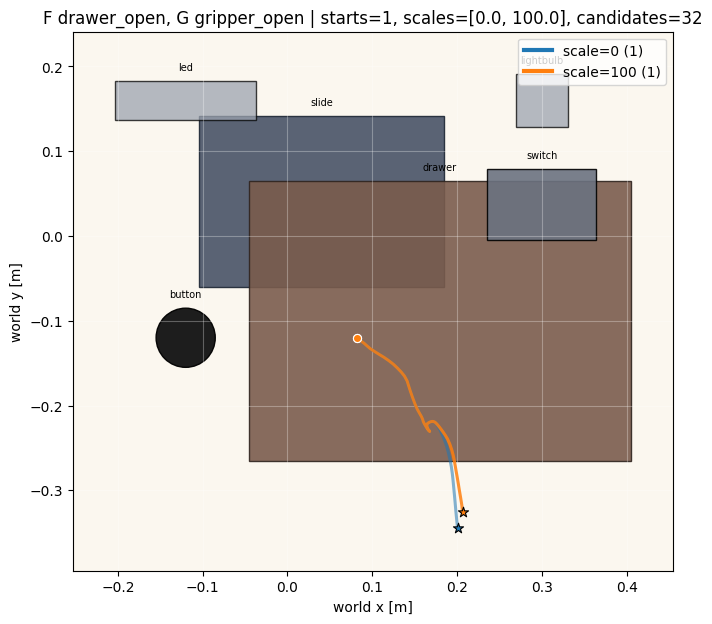

In [6]:
# Plot EEF XY trajectories, grouped by gripper guidance scale.
def plot_rollout_xy_by_scale(rollouts, scene_snapshot, title, save_path=None):
    paths = [np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts]
    scales = [float(r.get("guidance_scale", 0.0)) for r in rollouts]
    colors = {scale: plt.get_cmap("tab10")(i) for i, scale in enumerate(sorted(set(scales)))}
    all_xy = np.concatenate(paths, axis=0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)
    for rollout, xy, scale in zip(rollouts, paths, scales):
        color = colors[scale]
        alpha = 0.55 if scale == 0.0 else 0.85
        ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=2.2, alpha=alpha)
        ax.scatter(xy[0, 0], xy[0, 1], c=[color], s=34, edgecolors="white", linewidths=0.8, zorder=5)
        ax.scatter(xy[-1, 0], xy[-1, 1], c=[color], s=58, marker="*", edgecolors="black", linewidths=0.8, zorder=6)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, all_xy)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title); ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]"); ax.grid(alpha=0.3)
    handles = [Line2D([0], [0], color=colors[scale], lw=3, label=f"scale={scale:g} ({scales.count(scale)})") for scale in sorted(colors)]
    ax.legend(handles=handles, loc="upper right")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=100, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_rollout_xy_by_scale(
    rollouts, rollouts[0]["scene_snapshot"],
    title=f"F drawer_open, G gripper_open | starts={len(START_XY_LIST)}, scales={GUIDANCE_SCALES}, candidates={N_CANDIDATES}",
    save_path=run_dir / "rollouts_xy.png",
)


plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/20260521_035104/gripper_width_over_time.png


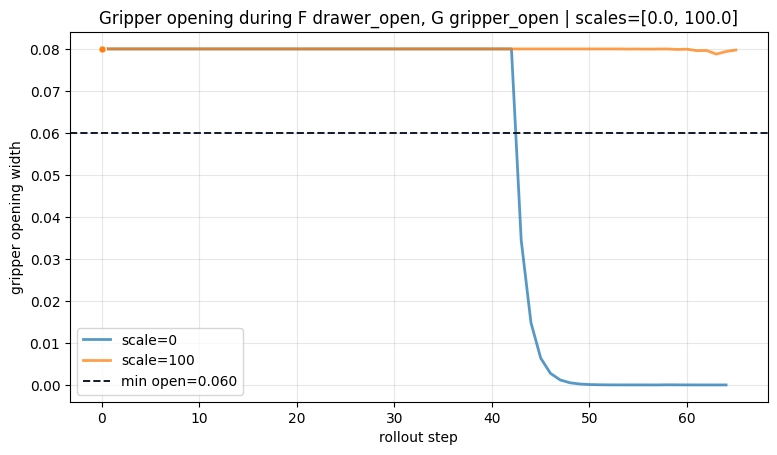

In [7]:
# Plot actual gripper opening width over rollout time for baseline vs guided execution.
def plot_gripper_width_over_time(rollouts, gripper_spec, title, save_path=None):
    scales = [float(r.get("guidance_scale", 0.0)) for r in rollouts]
    colors = {scale: plt.get_cmap("tab10")(i) for i, scale in enumerate(sorted(set(scales)))}

    fig, ax = plt.subplots(figsize=(9, 4.8))
    labeled_scales = set()
    for rollout, scale in zip(rollouts, scales):
        width = np.asarray(rollout["gripper_width"], dtype=np.float32)
        steps = np.arange(len(width))
        label = f"scale={scale:g}" if scale not in labeled_scales else None
        labeled_scales.add(scale)
        ax.plot(steps, width, color=colors[scale], linewidth=2.0, alpha=0.75, label=label)
        ax.scatter([steps[0]], [width[0]], c=[colors[scale]], s=28, edgecolors="white", linewidths=0.7, zorder=5)
    ax.axhline(gripper_spec.min_width, color="#111827", linestyle="--", linewidth=1.4, label=f"min open={gripper_spec.min_width:.3f}")
    ax.set_title(title); ax.set_xlabel("rollout step"); ax.set_ylabel("gripper opening width")
    ax.grid(alpha=0.3); ax.legend(loc="best")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=100, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_gripper_width_over_time(
    rollouts, GRIPPER_SPEC,
    title=f"Gripper opening during F drawer_open, G gripper_open | scales={GUIDANCE_SCALES}",
    save_path=run_dir / "gripper_width_over_time.png",
)


In [8]:
# Inspect local dynamics robustness updates for the selected action chunks.
rows = []
for rollout in rollouts:
    for record in rollout.get("records", []):
        grip = record["gripper"]
        rows.append({
            "seed": rollout["seed"], "start_xy": rollout["start_xy"], "scale": rollout["guidance_scale"], "t": record["t"],
            "score": record["selected_score"], "target_prob": record["selected_target_prob"],
            "robust_before": grip["robust_before"], "robust_after": grip["robust_after"],
            "min_width_before": grip["min_width_before"], "min_width_after": grip["min_width_after"],
            "action_l2_change": grip["action_l2_change"], "non_gripper_l2_change": grip.get("non_gripper_l2_change"),
            "gripper_l2_change": grip.get("gripper_l2_change"), "mode": grip.get("mode"),
        })

print("n refinement calls:", len(rows))
for row in rows[:20]:
    print(row)
if rows:
    print("median robustness improvement:", float(np.median([r["robust_after"] - r["robust_before"] for r in rows])))
    print("max action L2 change:", float(np.max([r["action_l2_change"] for r in rows])))

CRU.drop_env_quietly(globals(), name="env")


n refinement calls: 17
{'seed': 0, 'start_xy': [0.1, -0.1], 'scale': 0.0, 't': 0, 'score': 0.1388656198978424, 'target_prob': 0.5926192998886108, 'robust_before': -0.0010424518259242177, 'robust_after': -0.0010424518259242177, 'min_width_before': 0.07950965315103531, 'min_width_after': 0.07950965315103531, 'action_l2_change': 0.0, 'non_gripper_l2_change': 0.0, 'gripper_l2_change': 0.0, 'mode': 'disabled'}
{'seed': 0, 'start_xy': [0.1, -0.1], 'scale': 0.0, 't': 8, 'score': 0.9772222638130188, 'target_prob': 0.9906427264213562, 'robust_before': -0.0015354322968050838, 'robust_after': -0.0015354322968050838, 'min_width_before': 0.07866741716861725, 'min_width_after': 0.07866741716861725, 'action_l2_change': 0.0, 'non_gripper_l2_change': 0.0, 'gripper_l2_change': 0.0, 'mode': 'disabled'}
{'seed': 0, 'start_xy': [0.1, -0.1], 'scale': 0.0, 't': 16, 'score': 0.9979692101478577, 'target_prob': 0.9992257356643677, 'robust_before': -0.0017263960326090455, 'robust_after': -0.0017263960326090455, 

ven = NVIDIA Corporation
ven = NVIDIA Corporation
{'behavior': 'drawer_open', 'target_complete': True, 'termination_step': 65, 'termination_reason': 'target_complete', 'min_actual_gripper_width': 0.07877101004123688, 'records': 9, 'run_dir': '/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/wm_branch_diag_20260521_035114'}
plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_drawer_G_constraint/wm_branch_diag_20260521_035114/world_model_branch_diagnostics.png


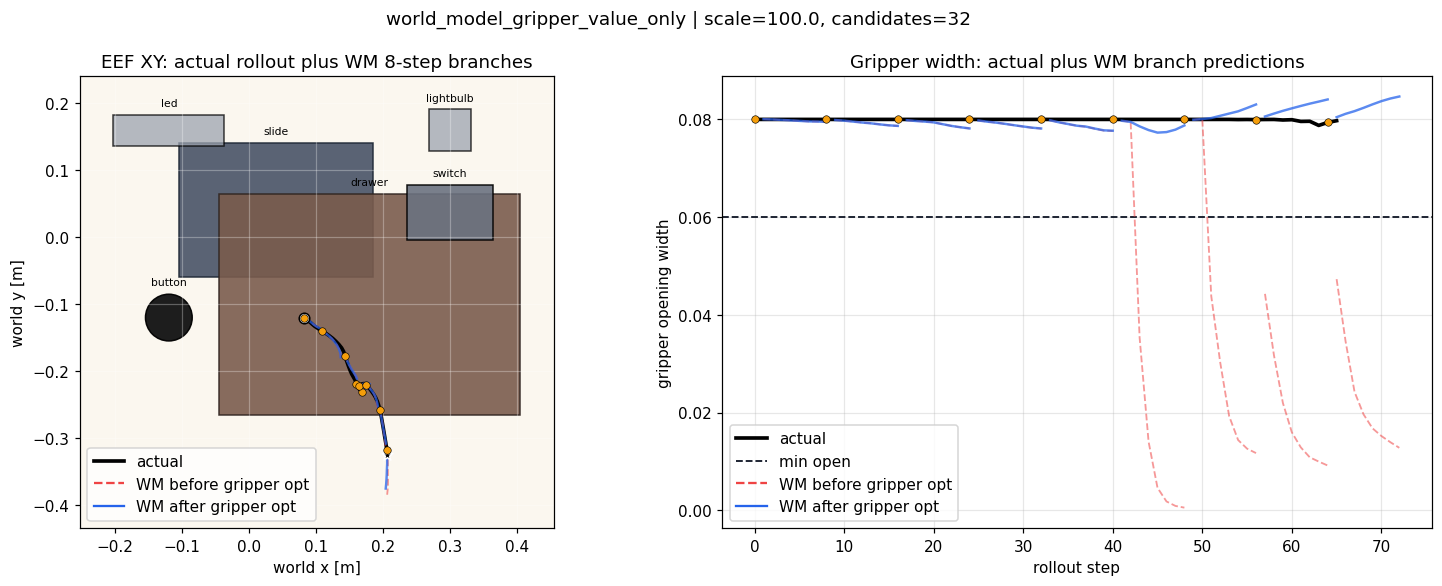

first branch records:
{'t': 0, 'selected_score': 0.1388656198978424, 'mode': 'world_model_gripper_value_only', 'min_width_before': 0.07950965315103531, 'min_width_after': 0.07951346784830093, 'non_gripper_l2_change': 0.0, 'gripper_l2_change': 0.0048785884864628315, 'gripper_before': [0.997, 0.999, 0.998, 1.0, 0.997, 1.0, 1.0, 1.0], 'gripper_after': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}
{'t': 8, 'selected_score': 0.9772222638130188, 'mode': 'world_model_gripper_value_only', 'min_width_before': 0.07866741716861725, 'min_width_after': 0.0786733403801918, 'non_gripper_l2_change': 0.0, 'gripper_l2_change': 0.05991528928279877, 'gripper_before': [0.999, 0.998, 0.999, 0.998, 0.997, 1.0, 0.998, 0.996], 'gripper_after': [1.0, 1.0, 1.0, 0.938, 1.0, 1.0, 1.0, 1.0]}
{'t': 16, 'selected_score': 0.9979692101478577, 'mode': 'world_model_gripper_value_only', 'min_width_before': 0.07815030962228775, 'min_width_after': 0.07815343886613846, 'non_gripper_l2_change': 0.0, 'gripper_l2_change': 0.0068156

In [9]:
# Diagnostic rollout: visualize world-model 8-step branches before/after raw gripper-width optimization.
# This cell is intentionally separate from the main experiment knobs above so it is easy to rerun while tuning.
WM_DIAG_SEED = 0
WM_DIAG_START_XY = (0.1, -0.1)
WM_DIAG_N_CANDIDATES = 32
WM_DIAG_HORIZON = 100
WM_DIAG_GUIDANCE_SCALE = 100.0
WM_DIAG_GRADIENT_STEPS = 50
WM_DIAG_STEP_SIZE = 0.10
WM_DIAG_ACTION_REG = 0.001
WM_DIAG_MODE = "world_model_gripper_value_only"  # raw predicted width objective, only action[-1] can change
WM_DIAG_SAVE_VIDEO = False

wm_diag_dir = OUTPUT_ROOT / f"wm_branch_diag_{time.strftime('%Y%m%d_%H%M%S')}"
wm_diag_dir.mkdir(parents=True, exist_ok=False)
wm_diag_sampler = make_drawer_gripper_action_sampler(
    TARGET_LABEL_IDX, WM_DIAG_N_CANDIDATES, GRIPPER_SPEC,
    guidance_scale=WM_DIAG_GUIDANCE_SCALE,
    gradient_steps=WM_DIAG_GRADIENT_STEPS,
    step_size=WM_DIAG_STEP_SIZE,
    action_reg=WM_DIAG_ACTION_REG,
    smooth_min_tau=SMOOTH_MIN_TAU,
    guidance_mode=WM_DIAG_MODE,
)
wm_diag_rollout = rollout_policy_once(
    seed=WM_DIAG_SEED,
    action_sampler=wm_diag_sampler,
    output_dir=wm_diag_dir,
    rollout_tag=f"{WM_DIAG_MODE}_seed_{WM_DIAG_SEED:03d}",
    horizon=WM_DIAG_HORIZON,
    save_video=WM_DIAG_SAVE_VIDEO,
    start_xy=WM_DIAG_START_XY,
)
print({
    "behavior": wm_diag_rollout["behavior"],
    "target_complete": wm_diag_rollout["target_complete"],
    "termination_step": wm_diag_rollout["termination_step"],
    "termination_reason": wm_diag_rollout["termination_reason"],
    "min_actual_gripper_width": float(np.min(wm_diag_rollout["gripper_width"])),
    "records": len(wm_diag_rollout["records"]),
    "run_dir": str(wm_diag_dir),
})

def plot_world_model_branch_diagnostics(rollout, scene_snapshot, save_path=None):
    xy = np.asarray(rollout["eef_xy"], dtype=np.float32)
    width = np.asarray(rollout["gripper_width"], dtype=np.float32)
    records = rollout.get("records", [])

    fig, (ax_xy, ax_w) = plt.subplots(1, 2, figsize=(14, 5.4))
    ax_xy.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax_xy, scene_snapshot)
    ax_xy.plot(xy[:, 0], xy[:, 1], color="black", linewidth=2.4, label="actual")
    ax_xy.scatter(xy[0, 0], xy[0, 1], c="white", s=48, edgecolors="black", zorder=5)
    ax_xy.scatter(xy[-1, 0], xy[-1, 1], c="black", s=55, marker="*", edgecolors="white", zorder=5)

    ax_w.plot(np.arange(len(width)), width, color="black", linewidth=2.4, label="actual")
    ax_w.axhline(GRIPPER_SPEC.min_width, color="#111827", linestyle="--", linewidth=1.2, label="min open")

    for record_idx, record in enumerate(records):
        grip = record.get("gripper", {})
        t0 = int(record["t"])
        if t0 >= len(xy):
            continue
        pred_xy_before = np.asarray(grip.get("pred_xy_before", []), dtype=np.float32)
        pred_xy_after = np.asarray(grip.get("pred_xy_after", []), dtype=np.float32)
        pred_w_before = np.asarray(grip.get("pred_width_before", []), dtype=np.float32)
        pred_w_after = np.asarray(grip.get("pred_width_after", []), dtype=np.float32)
        if pred_xy_before.size and pred_xy_after.size:
            before_xy = np.vstack([xy[t0], pred_xy_before])
            after_xy = np.vstack([xy[t0], pred_xy_after])
            ax_xy.plot(before_xy[:, 0], before_xy[:, 1], color="#ef4444", linestyle="--", linewidth=1.2, alpha=0.55)
            ax_xy.plot(after_xy[:, 0], after_xy[:, 1], color="#2563eb", linewidth=1.6, alpha=0.75)
            ax_xy.scatter(xy[t0, 0], xy[t0, 1], c="#f59e0b", s=24, edgecolors="black", linewidths=0.4, zorder=6)
        if pred_w_before.size and pred_w_after.size:
            steps = t0 + 1 + np.arange(len(pred_w_before))
            ax_w.plot(steps, pred_w_before, color="#ef4444", linestyle="--", linewidth=1.2, alpha=0.55)
            ax_w.plot(steps, pred_w_after, color="#2563eb", linewidth=1.6, alpha=0.75)
            ax_w.scatter([t0], [width[min(t0, len(width) - 1)]], c="#f59e0b", s=24, edgecolors="black", linewidths=0.4, zorder=6)

    all_pred_xy = []
    for record in records:
        grip = record.get("gripper", {})
        for key in ["pred_xy_before", "pred_xy_after"]:
            arr = np.asarray(grip.get(key, []), dtype=np.float32)
            if arr.size:
                all_pred_xy.append(arr)
    limit_points = xy if not all_pred_xy else np.vstack([xy] + all_pred_xy)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, limit_points)
    ax_xy.set_xlim(*xlim); ax_xy.set_ylim(*ylim)
    ax_xy.set_title("EEF XY: actual rollout plus WM 8-step branches")
    ax_xy.set_xlabel("world x [m]"); ax_xy.set_ylabel("world y [m]"); ax_xy.grid(alpha=0.3)
    ax_xy.plot([], [], color="#ef4444", linestyle="--", label="WM before gripper opt")
    ax_xy.plot([], [], color="#2563eb", label="WM after gripper opt")
    ax_xy.legend(loc="best")

    ax_w.set_title("Gripper width: actual plus WM branch predictions")
    ax_w.set_xlabel("rollout step"); ax_w.set_ylabel("gripper opening width")
    ax_w.grid(alpha=0.3)
    ax_w.plot([], [], color="#ef4444", linestyle="--", label="WM before gripper opt")
    ax_w.plot([], [], color="#2563eb", label="WM after gripper opt")
    ax_w.legend(loc="best")
    fig.suptitle(f"{WM_DIAG_MODE} | scale={WM_DIAG_GUIDANCE_SCALE}, candidates={WM_DIAG_N_CANDIDATES}")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_world_model_branch_diagnostics(
    wm_diag_rollout,
    wm_diag_rollout["scene_snapshot"],
    save_path=wm_diag_dir / "world_model_branch_diagnostics.png",
)

rows = []
for record in wm_diag_rollout.get("records", []):
    grip = record["gripper"]
    rows.append({
        "t": record["t"],
        "selected_score": record["selected_score"],
        "mode": grip.get("mode"),
        "min_width_before": grip["min_width_before"],
        "min_width_after": grip["min_width_after"],
        "non_gripper_l2_change": grip.get("non_gripper_l2_change"),
        "gripper_l2_change": grip.get("gripper_l2_change"),
        "gripper_before": np.round(grip.get("gripper_action_before", []), 3).tolist(),
        "gripper_after": np.round(grip.get("gripper_action_after", []), 3).tolist(),
    })
print("first branch records:")
for row in rows[:12]:
    print(row)


In [10]:
# Optional diagnostic: inspect gradients of predicted gripper width w.r.t. each action dimension.
# This checks whether the learned dynamics mostly attributes gripper width to action[-1], or leaks gradient into xyz/rpy.
GRAD_DIAG_SEED = 0
GRAD_DIAG_START_XY = (0.1, -0.1)
GRAD_DIAG_N_CANDIDATES = 32
GRAD_DIAG_MAX_STEPS = 80

def selected_drawer_chunk_for_grad_diag(obs, env, n_candidates=GRAD_DIAG_N_CANDIDATES):
    automaton_state, automaton_label = current_automaton_state_and_label(env)
    obs_tensor = policy._prepare_observation(obs)
    obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
    with torch.no_grad():
        action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
    action_chunks = unnormalize_action_sequence(action_chunk_n)
    candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
    candidate_scores = score_label_probs(candidate_probs, TARGET_LABEL_IDX)
    selected_idx = int(np.argmax(candidate_scores))
    return np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32), float(candidate_scores[selected_idx])

def gripper_width_gradient_report(env, action_chunk, name):
    state = env.get_state()
    state_dyn = raw_env_state_to_dynamics_state_torch(state["robot"], state["scene"])
    action_t = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32).clone().detach().requires_grad_(True)
    objective, width = raw_gripper_width_robustness_torch(state_dyn, action_t)
    objective.mean().backward()
    grad = action_t.grad[0].detach().cpu().numpy()
    absgrad = np.abs(grad)
    per_dim = absgrad.sum(axis=0)
    frac = per_dim / (per_dim.sum() + 1e-12)
    row = {
        "name": name,
        "gripper_cmd": np.round(action_chunk[:, -1], 3).tolist(),
        "pred_width": np.round(width[0].detach().cpu().numpy(), 4).tolist(),
        "objective_mean_width": float(objective[0].detach().cpu()),
        "abs_grad_sum_per_dim": np.round(per_dim, 6).tolist(),
        "abs_grad_frac_per_dim": np.round(frac, 4).tolist(),
        "grip_grad_by_step": np.round(grad[:, -1], 6).tolist(),
        "max_abs_non_grip_grad": float(absgrad[:, :6].max()),
        "max_abs_grip_grad": float(absgrad[:, -1].max()),
    }
    print(json.dumps(row, indent=2))
    return row

def run_gripper_gradient_diagnostic():
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(GRAD_DIAG_SEED), suppress_output=True)
    fixed_scene, fixed_robot, _ = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
    fixed_robot = robot_obs_with_target_xy(env, fixed_robot, GRAD_DIAG_START_XY)
    CRU.seed_everything(GRAD_DIAG_SEED)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)

    reports = []
    chunk0, score0 = selected_drawer_chunk_for_grad_diag(obs, env)
    reports.append(gripper_width_gradient_report(env, chunk0, f"selected open-ish chunk at t=0 score={score0:.3f}"))

    action_queue = []
    close_case = None
    step = 0
    while step < GRAD_DIAG_MAX_STEPS and close_case is None:
        if not action_queue:
            chunk, score = selected_drawer_chunk_for_grad_diag(obs, env)
            if np.min(chunk[:, -1]) < -0.5:
                close_case = (step, chunk.copy(), score)
                break
            action_queue.extend(chunk)
        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, _, done, _ = env.step(action)
        step += 1
        if done:
            break

    if close_case is not None:
        step, chunk, score = close_case
        reports.append(gripper_width_gradient_report(env, chunk, f"selected closing chunk at t={step} score={score:.3f}"))
    else:
        print(f"No selected closing chunk before step {GRAD_DIAG_MAX_STEPS}")
    CRU.drop_env_quietly(globals(), name="env")
    return reports

# Uncomment to run this diagnostic interactively.
# grad_reports = run_gripper_gradient_diagnostic()
